In [14]:
import pandas as pd
import numpy as np
import sklearn as skl
import mlflow as mlf
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
initDf = pd.read_csv("/home/angelbri/MLops/Actividad_1/adaptativePLC/Human_Machine_Adaptive_PLC_Reconfiguration_Dataset.csv")
initDf.head()

,Record_ID,Product_Type,Production_Mode,Machine_ID,PLC_Controller_Type,Task_ID,Task_Complexity_Level,Machine_Load_Percent,Sensor_Error_Rate,Human_Operator_ID,...,Digital_Twin_Safety_Score,Simulation_Cycle_Time_Sec,Energy_Consumption_kWh,Throughput_Units_Per_Hour,Downtime_Min,Safety_Risk_Level,Adaptability_Index,Human_Intervention_Count,Decision_Accuracy_Percent,Reconfiguration_Status
0,REC_00001,Automotive_Part,Batch,MCH_089,Mitsubishi_FX,TASK_0049,7,85.18,1.64,OP_059,...,65.42,44.93,16.45,52.01,17.13,Medium,64.56,5,68.36,Operator_Review_Required
1,REC_00002,Automotive_Part,Batch,MCH_081,Schneider_Modicon,TASK_0420,3,59.10,8.36,OP_050,...,48.62,54.01,12.51,120.13,5.03,Low,69.22,5,76.26,Unsafe_Configuration
2,REC_00003,Automotive_Part,Flexible,MCH_060,Allen_Bradley,TASK_0380,4,54.64,4.47,OP_041,...,80.29,86.34,31.54,125.14,17.60,Medium,88.17,0,88.92,Successful_Reconfiguration
3,REC_00004,Custom_Component,Job_Shop,MCH_091,Allen_Bradley,TASK_0035,9,97.17,6.59,OP_101,...,53.71,60.81,32.51,132.87,19.74,High,75.63,5,80.74,Unsafe_Configuration
4,REC_00005,Automotive_Part,Flexible,MCH_071,Omron_CP,TASK_0187,1,80.47,2.08,OP_086,...,65.76,35.70,23.16,173.00,14.86,Medium,69.52,7,76.14,Operator_Review_Required


In [3]:
initDf.info()

<class 'pandas.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 35 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Record_ID                           11500 non-null  str    
 1   Product_Type                        11500 non-null  str    
 2   Production_Mode                     11500 non-null  str    
 3   Machine_ID                          11500 non-null  str    
 4   PLC_Controller_Type                 11500 non-null  str    
 5   Task_ID                             11500 non-null  str    
 6   Task_Complexity_Level               11500 non-null  int64  
 7   Machine_Load_Percent                11500 non-null  float64
 8   Sensor_Error_Rate                   11500 non-null  float64
 9   Human_Operator_ID                   11500 non-null  str    
 10  Operator_Experience_Level           11500 non-null  str    
 11  Manual_Programming_Time_Min         11500 non-null  

In [4]:
# Dropping the columns
cols=[
    "Record_ID",
    "Human_Operator_ID",
    "Task_ID",
    "Machine_ID",
    "Predicted_Reconfiguration_Time_Min",
    "Decision_Accuracy_Percent",
    "XAI_Explanation_Score",
    "Operator_Trust_Score",
    "Operator_Validation_Status",
    "Reconfiguration_Status",
    "System_State_Complexity",
    "Machine_Task_Dependency_Score",
    "Knowledge_Graph_Dependency_Count"
]
df=initDf.drop(columns=[col for col in cols if col in initDf.columns])
df.head()

,Product_Type,Production_Mode,PLC_Controller_Type,Task_Complexity_Level,Machine_Load_Percent,Sensor_Error_Rate,Operator_Experience_Level,Manual_Programming_Time_Min,Previous_Reconfiguration_Time_Min,Product_Customization_Level,...,Auto_Code_Generation_Time_Sec,PLC_Code_Error_Count,Digital_Twin_Safety_Score,Simulation_Cycle_Time_Sec,Energy_Consumption_kWh,Throughput_Units_Per_Hour,Downtime_Min,Safety_Risk_Level,Adaptability_Index,Human_Intervention_Count
0,Automotive_Part,Batch,Mitsubishi_FX,7,85.18,1.64,Medium,152.07,83.72,7,...,29.03,4,65.42,44.93,16.45,52.01,17.13,Medium,64.56,5
1,Automotive_Part,Batch,Schneider_Modicon,3,59.10,8.36,Expert,246.73,128.68,3,...,22.55,2,48.62,54.01,12.51,120.13,5.03,Low,69.22,5
2,Automotive_Part,Flexible,Allen_Bradley,4,54.64,4.47,Low,185.59,176.67,2,...,51.36,0,80.29,86.34,31.54,125.14,17.60,Medium,88.17,0
3,Custom_Component,Job_Shop,Allen_Bradley,9,97.17,6.59,Expert,113.44,98.98,3,...,158.10,1,53.71,60.81,32.51,132.87,19.74,High,75.63,5
4,Automotive_Part,Flexible,Omron_CP,1,80.47,2.08,High,90.34,200.89,9,...,110.12,4,65.76,35.70,23.16,173.00,14.86,Medium,69.52,7


In [5]:
print(df.isnull().sum())

Product_Type                         0
Production_Mode                      0
PLC_Controller_Type                  0
Task_Complexity_Level                0
Machine_Load_Percent                 0
Sensor_Error_Rate                    0
Operator_Experience_Level            0
Manual_Programming_Time_Min          0
Previous_Reconfiguration_Time_Min    0
Product_Customization_Level          0
Double_DQN_Action_ID                 0
DQN_Confidence_Score                 0
Auto_Code_Generation_Time_Sec        0
PLC_Code_Error_Count                 0
Digital_Twin_Safety_Score            0
Simulation_Cycle_Time_Sec            0
Energy_Consumption_kWh               0
Throughput_Units_Per_Hour            0
Downtime_Min                         0
Safety_Risk_Level                    0
Adaptability_Index                   0
Human_Intervention_Count             0
dtype: int64


In [6]:
print(df.shape)

(11500, 22)


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Product_Type                       11500 non-null  str    
 1   Production_Mode                    11500 non-null  str    
 2   PLC_Controller_Type                11500 non-null  str    
 3   Task_Complexity_Level              11500 non-null  int64  
 4   Machine_Load_Percent               11500 non-null  float64
 5   Sensor_Error_Rate                  11500 non-null  float64
 6   Operator_Experience_Level          11500 non-null  str    
 7   Manual_Programming_Time_Min        11500 non-null  float64
 8   Previous_Reconfiguration_Time_Min  11500 non-null  float64
 9   Product_Customization_Level        11500 non-null  int64  
 10  Double_DQN_Action_ID               11500 non-null  int64  
 11  DQN_Confidence_Score               11500 non-null  float64
 12  A

In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Type,11500,5,Automotive_Part,2372,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Production_Mode,11500,4,Job_Shop,2948,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PLC_Controller_Type,11500,5,Mitsubishi_FX,2344,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Task_Complexity_Level,11500.0,NaN,NaN,NaN,5.529826,2.881109,1.0,3.0,6.0,8.0,10.0
Machine_Load_Percent,11500.0,NaN,NaN,NaN,66.430266,18.171156,35.01,50.8175,66.28,82.19,97.99
Sensor_Error_Rate,11500.0,NaN,NaN,NaN,4.318142,2.430623,0.1,2.18,4.34,6.39,8.5
Operator_Experience_Level,11500,4,Low,2929,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Manual_Programming_Time_Min,11500.0,NaN,NaN,NaN,176.33415,58.612911,51.29,127.5425,176.675,224.9775,299.43
Previous_Reconfiguration_Time_Min,11500.0,NaN,NaN,NaN,128.957361,43.359533,39.25,92.73,128.795,164.9625,219.97
Product_Customization_Level,11500.0,NaN,NaN,NaN,5.488,2.886787,1.0,3.0,5.0,8.0,10.0


In [9]:
#Numerical Columns:
numCols = ['Task_Complexity_Level', 'Machine_Load_Percent', 'Sensor_Error_Rate', 'Manual_Programming_Time_Min', 'Previous_Reconfiguration_Time_Min', 'Product_Customization_Level', 'Double_DQN_Action_ID', 'DQN_Confidence_Score', 'Auto_Code_Generation_Time_Sec', 'PLC_Code_Error_Count', 'Digital_Twin_Safety_Score', 'Simulation_Cycle_Time_Sec', 'Energy_Consumption_kWh', 'Throughput_Units_Per_Hour', 'Downtime_Min', 'Adaptability_Index', 'Human_Intervention_Count']

#Categorical Columns:
catCols = ['Product_Type', 'Production_Mode', 'PLC_Controller_Type', 'Operator_Experience_Level', 'Safety_Risk_Level']

In [10]:
stats=df.describe().T
stats['skewness']=df.skew(numeric_only=True)
stats['kurtosis']=df.kurtosis(numeric_only=True)
stats

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Task_Complexity_Level,11500.0,5.529826,2.881109,1.00,3.0000,6.000,8.0000,10.00,-0.006475,-1.229538
Machine_Load_Percent,11500.0,66.430266,18.171156,35.01,50.8175,66.280,82.1900,97.99,0.001759,-1.204151
Sensor_Error_Rate,11500.0,4.318142,2.430623,0.10,2.1800,4.340,6.3900,8.50,-0.011006,-1.199426
Manual_Programming_Time_Min,11500.0,176.334150,58.612911,51.29,127.5425,176.675,224.9775,299.43,-0.022755,-1.013472
Previous_Reconfiguration_Time_Min,11500.0,128.957361,43.359533,39.25,92.7300,128.795,164.9625,219.97,0.014407,-1.040886
Product_Customization_Level,11500.0,5.488000,2.886787,1.00,3.0000,5.000,8.0000,10.00,-0.000722,-1.231498
Double_DQN_Action_ID,11500.0,5.461739,3.459129,0.00,2.0000,5.000,8.0000,11.00,0.006487,-1.223335
DQN_Confidence_Score,11500.0,0.769261,0.126255,0.55,0.6610,0.769,0.8780,0.99,0.007863,-1.196660
Auto_Code_Generation_Time_Sec,11500.0,100.018134,46.188506,20.01,59.9300,100.125,140.0700,179.98,0.000419,-1.198617
PLC_Code_Error_Count,11500.0,2.954870,1.842044,0.00,1.0000,3.000,4.0000,7.00,0.488212,-0.448253


In [12]:
# Outlier counts using IQR
Q1=df[numCols].quantile(0.25)
Q3=df[numCols].quantile(0.75)
IQR=Q3-Q1
outliers=((df[numCols]<(Q1-1.5*IQR))|(df[numCols]>(Q3+1.5*IQR)))
outliers.sum().sort_values(ascending=False)

Digital_Twin_Safety_Score            19
Adaptability_Index                    1
Task_Complexity_Level                 0
Machine_Load_Percent                  0
Sensor_Error_Rate                     0
Product_Customization_Level           0
Double_DQN_Action_ID                  0
Manual_Programming_Time_Min           0
Previous_Reconfiguration_Time_Min     0
Auto_Code_Generation_Time_Sec         0
DQN_Confidence_Score                  0
Simulation_Cycle_Time_Sec             0
PLC_Code_Error_Count                  0
Energy_Consumption_kWh                0
Throughput_Units_Per_Hour             0
Downtime_Min                          0
Human_Intervention_Count              0
dtype: int64

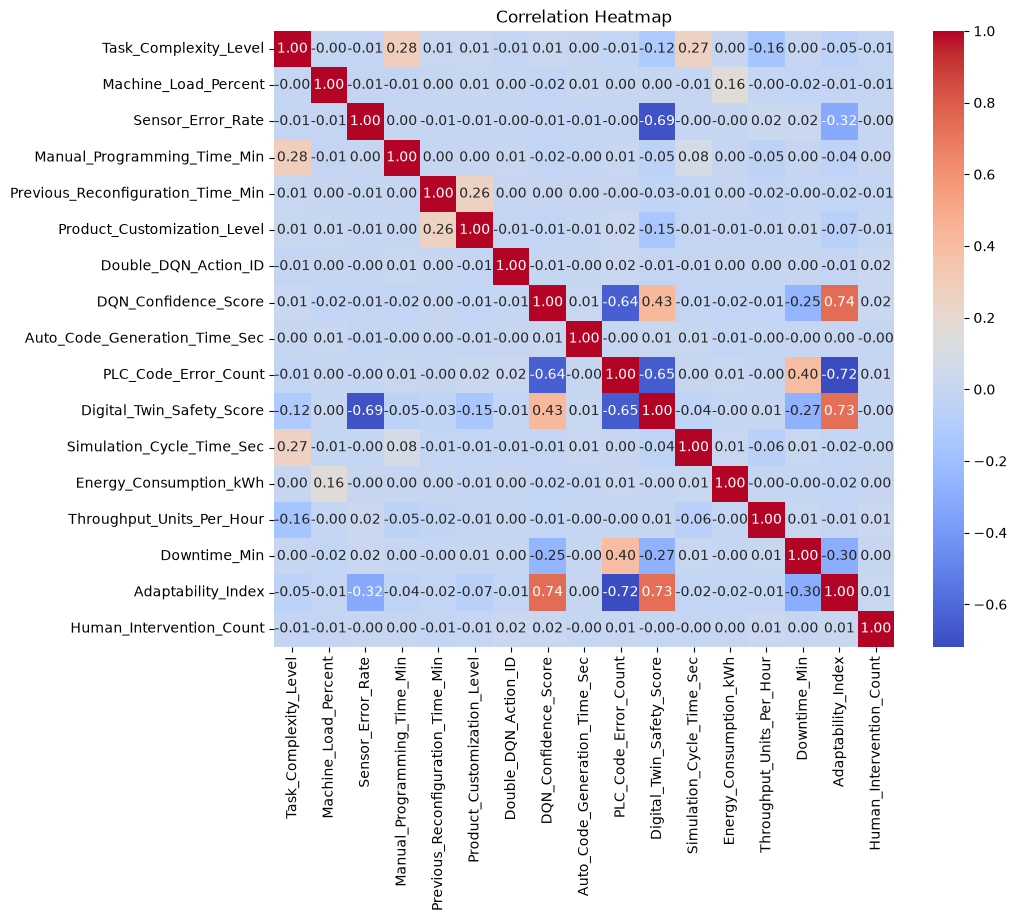

In [15]:
# Making Correlation Matrix
plt.figure(figsize=(10,8))
corr=df.select_dtypes(include=np.number).corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig('correlation_matrix_dashboard.png',bbox_inches='tight',dpi=300)
plt.show()

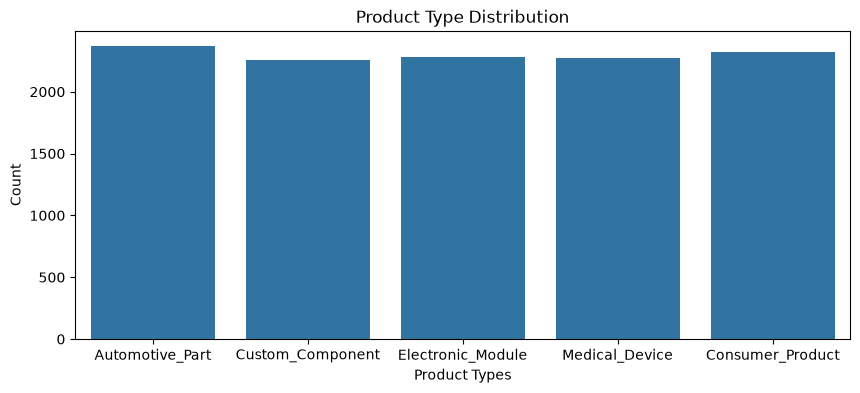

In [16]:
# Product Type bar graph
plt.figure(figsize=(10,4))
sns.countplot(x='Product_Type',data=df)
plt.title("Product Type Distribution")
plt.xlabel("Product Types")
plt.ylabel("Count")
plt.savefig('Product_Distribution_dashboard.png',bbox_inches='tight',dpi=300)
plt.show()

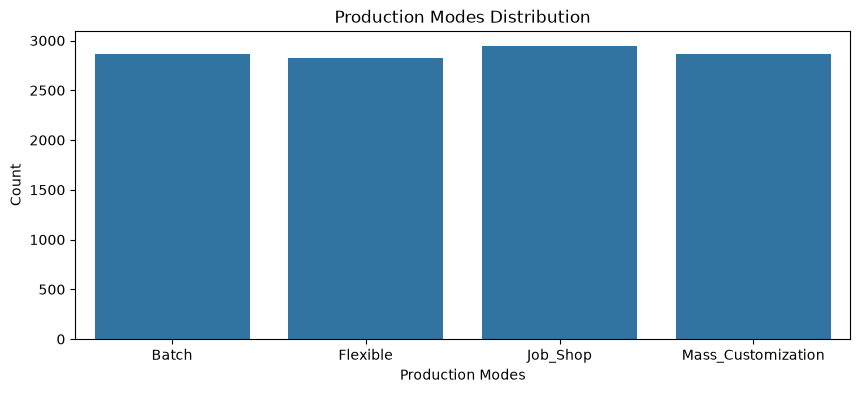

In [17]:
# Product Mode bar graph
plt.figure(figsize=(10,4))
sns.countplot(x='Production_Mode',data=df)
plt.title("Production Modes Distribution")
plt.xlabel("Production Modes")
plt.ylabel("Count")
plt.savefig('Production_Modes_dashboard.png',bbox_inches='tight',dpi=300)
plt.show()

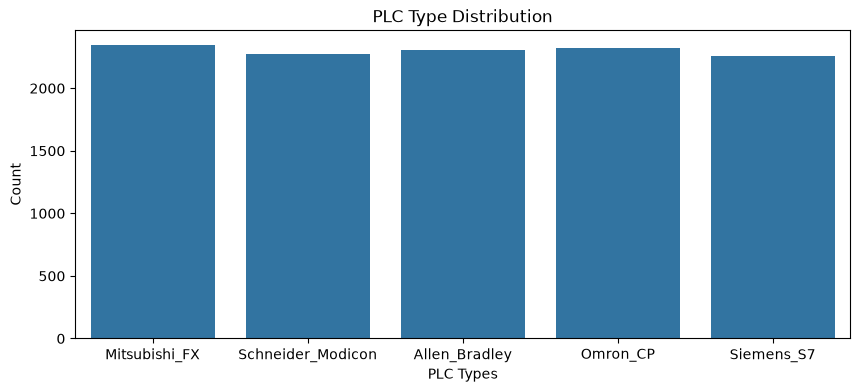

In [18]:
# PLC Type bar graph
plt.figure(figsize=(10,4))
sns.countplot(x='PLC_Controller_Type',data=df)
plt.title("PLC Type Distribution")
plt.xlabel("PLC Types")
plt.ylabel("Count")
plt.savefig('PLC_Distribution_dashboard.png',bbox_inches='tight',dpi=300)
plt.show()

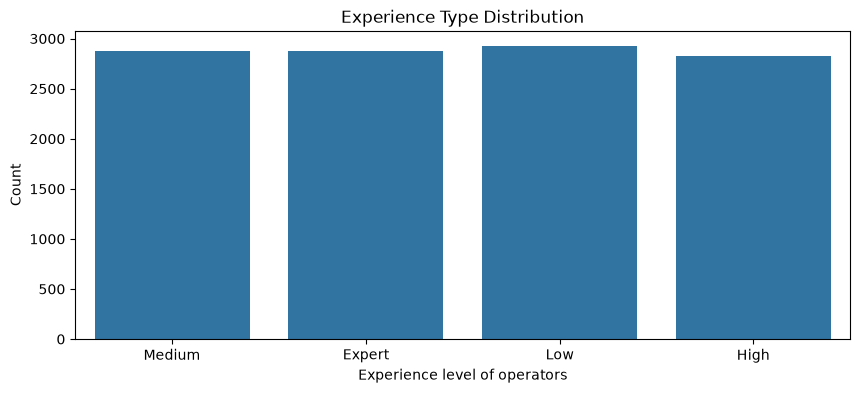

In [19]:
# Operator bar graph
plt.figure(figsize=(10,4))
sns.countplot(x='Operator_Experience_Level',data=df)
plt.title("Experience Type Distribution")
plt.xlabel("Experience level of operators")
plt.ylabel("Count")
plt.savefig('Experience_levels_dashboard.png',bbox_inches='tight',dpi=300)
plt.show()

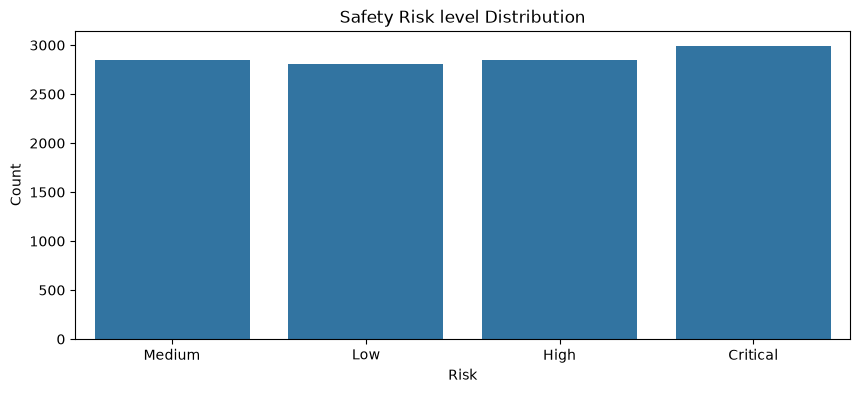

In [20]:
# Safety Risk bar graph
plt.figure(figsize=(10,4))
sns.countplot(x='Safety_Risk_Level',data=df)
plt.title("Safety Risk level Distribution")
plt.xlabel("Risk")
plt.ylabel("Count")
plt.savefig('Risk_dashboard.png',bbox_inches='tight',dpi=300)
plt.show()

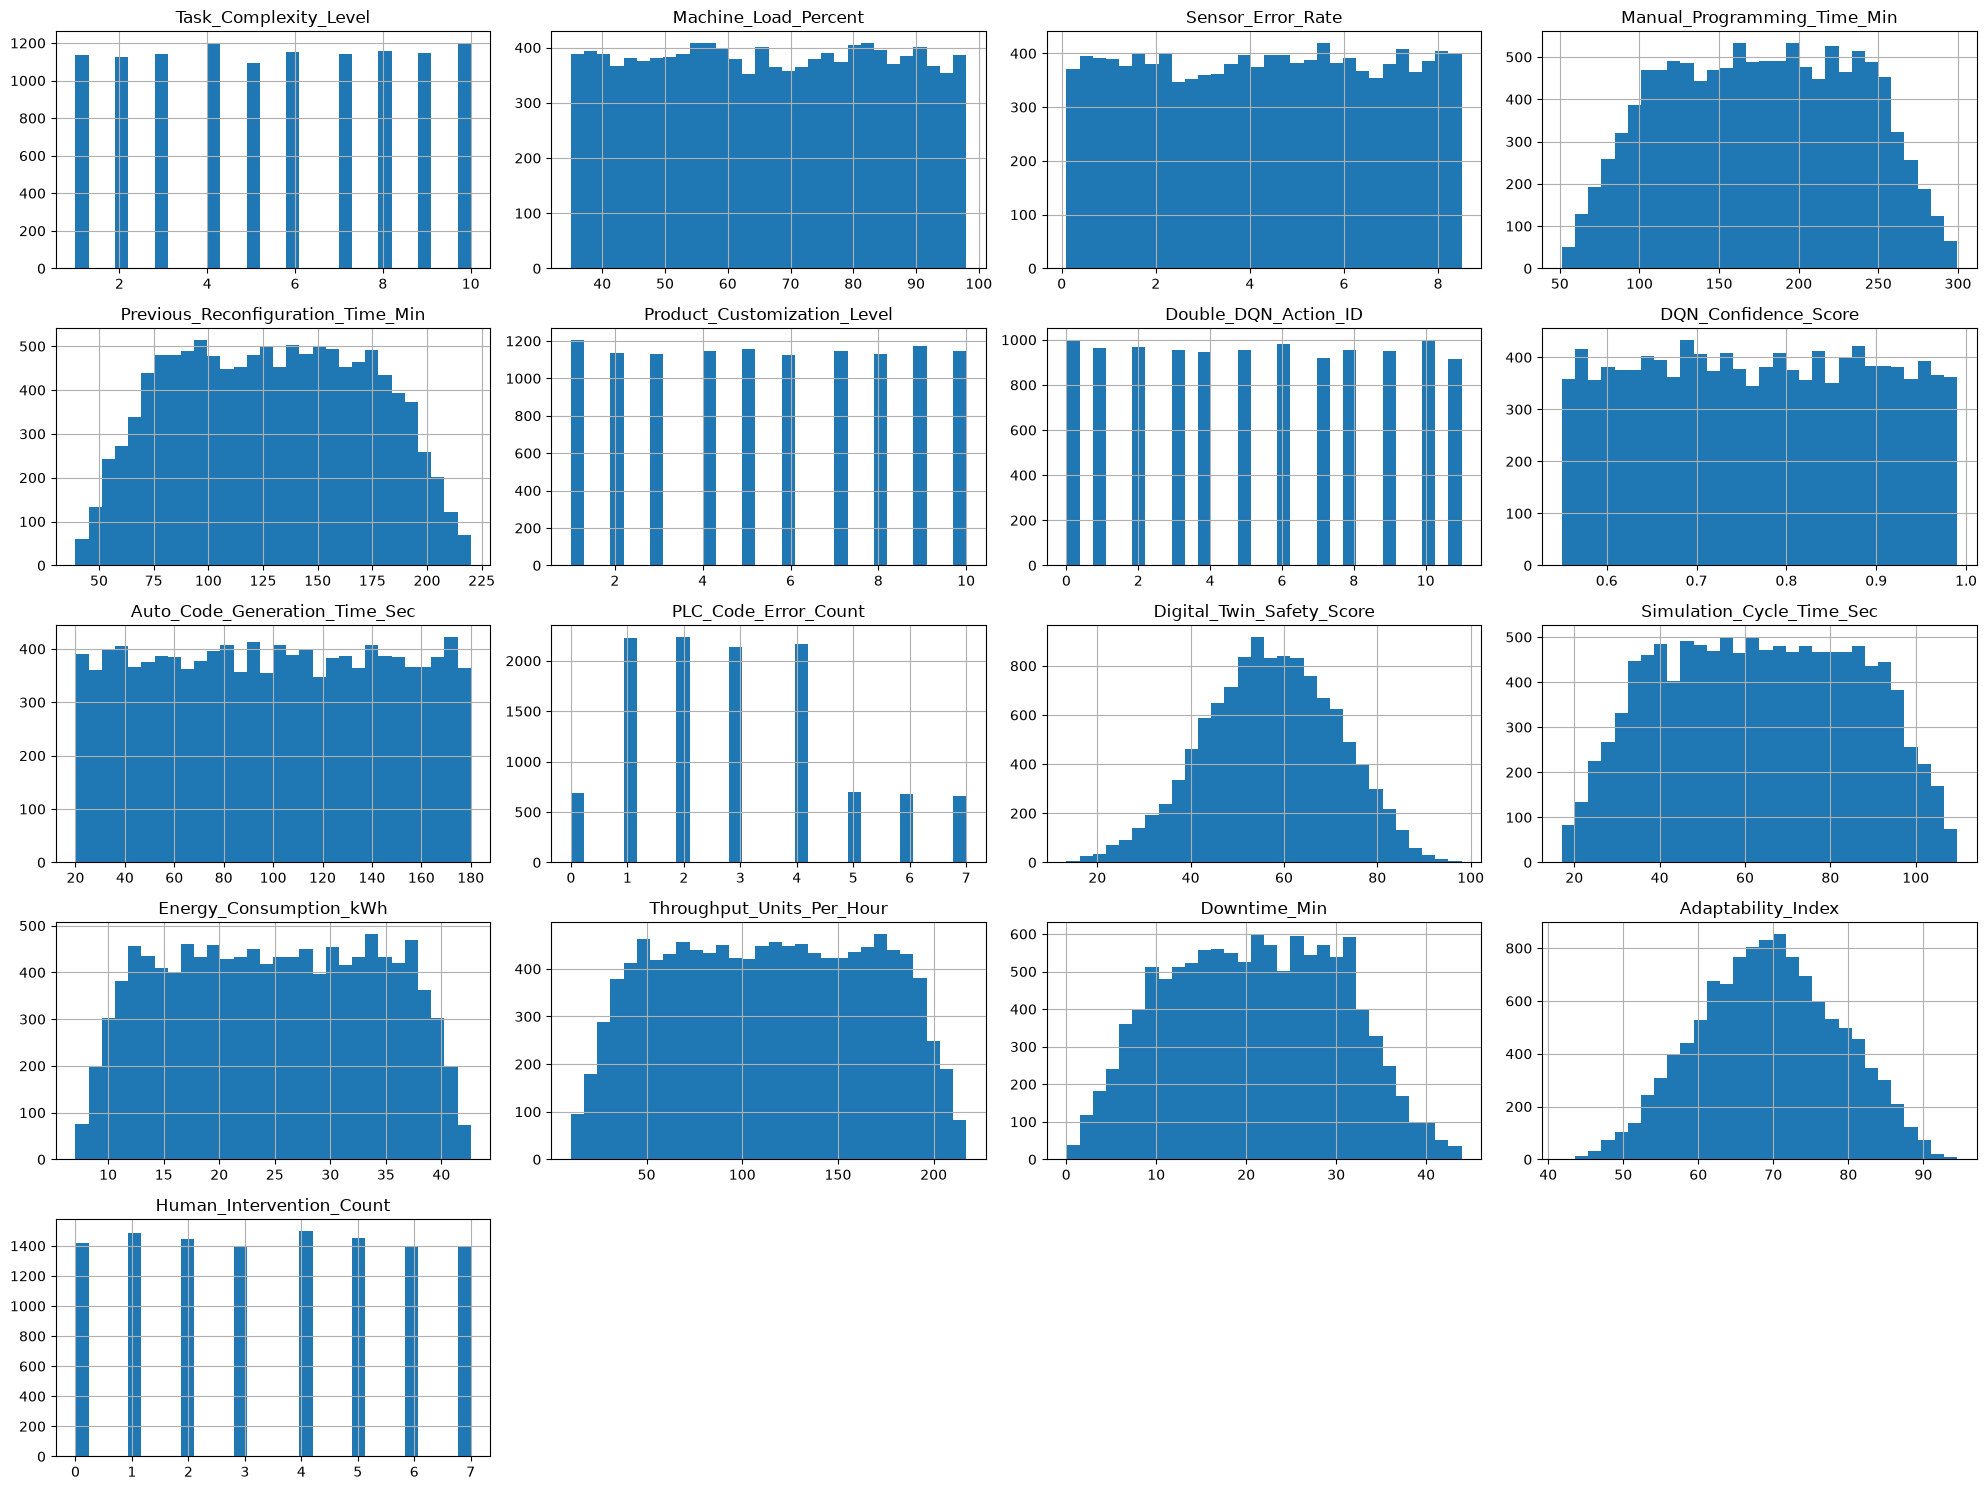

In [21]:
# Numerical Feature Distribution
num_cols=df.select_dtypes(include=np.number).columns
df[num_cols].hist(figsize=(20,15),bins=30)
plt.tight_layout()
plt.savefig('Feature_Distribution_dashboard.png',bbox_inches='tight',dpi=300)
plt.show()